In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model='text-embedding-3-large')
vector_store = Chroma(
    embedding_function=embeddings,
    collection_name='income_tax_collection',
    persist_directory='./income_tax_collection'
)

retriever = vector_store.as_retriever(search_kwargs={'k': 3})


In [3]:
# START -> RETRIEVE -> GENERATE -> END

from typing_extensions import TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str
    context: list
    answer: str

graph_builder = StateGraph(AgentState)

In [4]:
def retrieve(state: AgentState):
    query = state['query']
    docs = retriever.invoke(query)
    return {'context': docs}    

In [5]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o')

In [6]:
from langchain import hub
from langchain_core.output_parsers import StrOutputParser

generate_prompt = hub.pull('rlm/rag-prompt')
generate_llm = ChatOpenAI(model='gpt-4o', max_tokens=100)
def generate(state: AgentState) -> AgentState:
    context = state['context']
    query = state['query']
    rag_chain = generate_prompt | llm | StrOutputParser()
    response = rag_chain.invoke({'question': query, 'context': context})
    return {'answer': response}

/Users/jys/code/study/study-llm-agent/venv/lib/python3.11/site-packages/langsmith/client.py:278: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


In [7]:
from langchain import hub
from typing import Literal

# 질문과 document의 연관성이 얼마나 되는지 확인하는 rag-document-relevance 프롬프트
doc_relevance_prompt = hub.pull('langchain-ai/rag-document-relevance')

# self-rag에서는 END를 호출을 해야 하는데, END는 노드가 아니기 떄문에, Literal을 해도 에러가 발생한다. 따라서 엣지에서 처리해야 한다.
# 질문이 문서와 얼마나 연관성이 있는지 체크하는 노드
def check_doc_relevance(state: AgentState) -> Literal['relevant', 'irrelevant']:
    context = state['context']
    query = state['query']
    doc_relevance_chain = doc_relevance_prompt | llm
    response = doc_relevance_chain.invoke({'question': query, 'documents': context})
    if response['Score'] == 1:
        return 'relevant'
    return 'irrelevant'

/Users/jys/code/study/study-llm-agent/venv/lib/python3.11/site-packages/langsmith/client.py:278: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


In [8]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

# 웹 검색을 해서 가져올 것이기 떄문에 사전이 필요가 없다.
# dictionary = ['사람과 관련된 표현 -> 거주자']

rewrite_prompt = PromptTemplate.from_template(f"""
    사용자의 질문을 보고, 웹 검색에 용이하게 사용자의 질문을 수정해주세요
    질문: {{query}}
"""
)

# 사용자의 질문을 변경해주는 노드
def rewrite(state: AgentState):
    query = state['query']
    rewrite_chain = rewrite_prompt | llm | StrOutputParser()
    response = rewrite_chain.invoke({'query': query})
    return {'query': response}


In [9]:
%pip install -qU langchain-tavily


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [10]:
from langchain_tavily import TavilySearch

tavily_search_tool = TavilySearch(
    max_results=3,
    topic="general",
)

def web_search(state: AgentState):
    query = state['query']
    response = tavily_search_tool.invoke(query)
    return {'context': response}

In [11]:
graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('generate', generate)
graph_builder.add_node('rewrite', rewrite)
graph_builder.add_node('web_search', web_search)


In [12]:
from langgraph.graph import START, END

# START -> RETRIEVE(문서에서 가져와서) -> 관련이 있으면 바로 generate-> REWRITE 없으면 rewrite 해서 웹 검색에 용이한 질문으로 변경 -> WEB_SEARCH -> GENERATE -> END
graph_builder.add_edge(START, 'retrieve')
graph_builder.add_conditional_edges(
    'retrieve',
    check_doc_relevance,
    {
        'relevant': 'generate',
        'irrelevant': 'rewrite'
    }
)
graph_builder.add_edge('rewrite', 'web_search')
graph_builder.add_edge('web_search', 'generate')
graph_builder.add_edge('generate', END)

In [13]:
graph = graph_builder.compile()

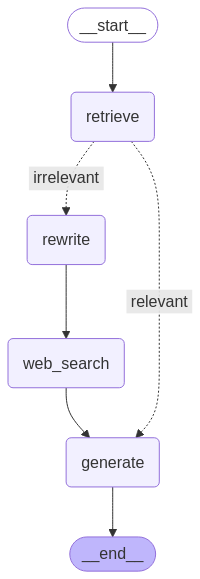

In [15]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))



In [14]:
inital_state = {'query': '소득세 계산 방법'}
graph.invoke(inital_state)

{'query': '소득세 계산 방법',
 'context': [Document(id='7b75a7dc-4335-41c1-8f4b-3feee5f3f85c', metadata={'source': './documents/income_tax.txt'}, page_content='자. 법인·조례에 따른 위월환 등의 보수를 받지 아니하는 위험(학생의 및 예술원회의 회원을 포함한다) 등이 받는 수당\n[전문개정 2009. 12. 31.]\n제13조 삭제 <2009. 12. 31.>\n제2장 과세표준과 세액의 개산 개정 2009. 12. 31.\n제1난 세액계산 통칙 개정 2009. 12. 31.\n제14조(과세표준의 개산)\n① 거주자의 종합소득 및 퇴직소득에 대한 과세표준은 각각 구분하여 계산한다.\n② 종합소득에 대한 과세표준(이하 “종합소득과세표준”이라 한다)은 제16조, 제19조, 제20조의3, 제21조, 제20조부터 제20조까지, 제21조부터 제29조까지, 제31조부터 제35조까지, 제37조, 제39조, 제42조부터 제46조까지, 제46조의2, 제47조 및 제47조의2에 따라 이자소득금액, 배당소득금액, 사업소득금액, 근로소득금액, 연금소득금액 및 기타소득금액의 합계액(이하 “종합소득금액”이라 한다)에 의하여 제20조, 제21조, 제51조의2, 제51조의3 및 제52조에 따른 경우(이하 “종합소득금액지”라 한다) 적용한 규정으로 한다. <개정 2013. 1. 1., 2014. 1. 1.>\n③ 다음 각 호에 따른 소득의 금액은 종합소득과세표준을 계산할 때 포함하지 아니한다. <개정 2010. 12. 27, 2011. 7. 14, 2013. 1. 1, 2014. 12. 23, 2015. 12. 15, 2017. 12. 19, 2018. 12. 31, 2019. 12. 31, 2020. 12. 29, 2023. 12. 31.>\n①조 세특례제한법, 또는 이 법 제12조에 따른 과세제외 소득\n대통령령으로 정하는 임금소득(이하 “임금소득”이라 한다)과 근로소득  \n

In [16]:
inital_state = {'query': '강남역 버거집'}
graph.invoke(inital_state)

{'query': '"강남역 근처 맛있는 버거집 추천"',
 'context': {'query': '"강남역 근처 맛있는 버거집 추천"',
  'follow_up_questions': None,
  'answer': None,
  'images': [],
  'results': [{'url': 'https://www.diningcode.com/list.dc?query=%EA%B0%95%EB%82%A8%EC%97%AD%20%EC%88%98%EC%A0%9C%EB%B2%84%EA%B1%B0',
    'title': "'강남역 수제버거' 맛집 빅데이터 추천순위 Top23 - 다이닝코드",
    'content': '강남역 수제버거맛집 (23곳) · 1. 바스버거 역삼 · 2. 위트앤미트 강남점 · 3. 파이브가이즈 강남 · 4. 쉑쉑버거 강남대로점 · 5. 데일리픽스 강남역 · 6. 힘난다버거 신논현역점.',
    'score': 0.878825,
    'raw_content': None},
   {'url': 'https://www.diningcode.com/list.dc?query=%EA%B0%95%EB%82%A8%EC%97%AD%20%20%ED%96%84%EB%B2%84%EA%B1%B0',
    'title': "'강남역 햄버거' 맛집 빅데이터 추천순위 Top37 - 다이닝코드",
    'content': '강남역 햄버거맛집 (37곳) · 1. 파이브가이즈 강남 · 2. 위트앤미트 강남점 · 3. 쉑쉑버거 강남대로점 · 4. 바스버거 역삼 · 5. 데일리픽스 강남역 · 6. 맥도날드 강남2호점 · 7.',
    'score': 0.86928266,
    'raw_content': None},
   {'url': 'https://m.blog.naver.com/PostView.naver?blogId=dlawlrb123&logNo=223705047309',
    'title': '강남역 점심 미슐랭 출신 셰프의 미국식 수제버거 맛집 다비치 강민경 ..